In [1]:
import pandas as pd, numpy as np
import argparse
import pickle
import ast
import pandas as pd
from sklearn.utils import resample
import matplotlib.pyplot as plt
import re

In [2]:
def pickle_to_res(path):
    with open(path, "rb") as f:
        raw_pickle = pickle.load(f)

    results = {}
    answer_prefix="Answer Choice "
    
    def extract_ans(ans_str, search_substring):
        # Split the string into lines
        lines = ans_str.split("/n")

        for line in lines:
            # Check if the line starts with the specified substring
            if line.startswith(search_substring):
                # If it does, add it to the list of extracted rows
                return line[len(search_substring) :].strip()
        return "ERROR"  # Answer not found

    for k, v in raw_pickle.items():
        if k != 'token_usage':  # Skip token_usage
            qns_idx = ast.literal_eval(k)
            for idx, qn_idx in enumerate(qns_idx):
                results[qn_idx] = extract_ans(
                    v[0], f"{answer_prefix}{idx+1}:"
                )  # We start with question 1
    
    return results



In [3]:
def res_to_vec(res):
    test_df = pd.read_csv('C:/Users/sonne/Documents/Github/biasICL/ddi_test_metadata.csv', index_col=0)
    num_errors = 0
    labels, preds, race = [], [], []
    for i in test_df.itertuples():
        fst = '12' if i.skin_tone == 12 else '56'
        if (i.Index not in res) or (res[i.Index].startswith("ERROR")):
            num_errors += 1

            print(i.Index, f"answer not found")
            continue

        pred_text = res[i.Index]
        ground_truth = "B" if i.malignant == True else "A"
        labels.append(ground_truth)
        preds.append(pred_text)
        race.append(fst)
        
    print(f"In total {num_errors} errors len = {len(labels)}")
    return labels,preds,race

In [4]:
def calculate_metrics(actual, predicted):
    TP = sum((a == 'B' and p == 'B') for a, p in zip(actual, predicted))
    TN = sum((a == 'A' and p == 'A') for a, p in zip(actual, predicted))
    FP = sum((a == 'A' and p == 'B') for a, p in zip(actual, predicted))
    FN = sum((a == 'B' and p == 'A') for a, p in zip(actual, predicted))
    
    precision = TP / (TP + FP) if (TP + FP) > 0 else 0
    recall = TP / (TP + FN) if (TP + FN) > 0 else 0
    
    # Calculate F1 score
    if precision + recall > 0:
        f1_score = 2 * (precision * recall) / (precision + recall)
    else:
        f1_score = 0
    
    accuracy = (TP + TN) / len(actual)
    tpr = TP / (TP + FN) if (TP + FN) > 0 else 0
    tnr = TN / (TN + FP) if (TN + FP) > 0 else 0
    
    return accuracy, tpr, tnr, f1_score



def filter_by_race(actual, predicted, race, race_value):
    filtered_actual = [a for a, r in zip(actual, race) if r == race_value]
    filtered_predicted = [p for p, r in zip(predicted, race) if r == race_value]
    return filtered_actual, filtered_predicted

def calculate_bootstrap_metrics(exps):
    """
    Calculate bootstrap metrics for all experiments
    """
    bulk_metrics = {'mean': [], 'std': []}
    fst12_metrics = {'mean': [], 'std': []}
    fst56_metrics = {'mean': [], 'std': []}
    
    for exp in exps:
        results = pickle_to_res(exp)
        labels, preds, race = res_to_vec(results)
        
        # Calculate bulk metrics
        bulk_mean, bulk_std = bootstrap_metrics(labels, preds)
        bulk_metrics['mean'].append(bulk_mean)
        bulk_metrics['std'].append(bulk_std)
        
        # Calculate FST 1/2 metrics
        fst12_mean, fst12_std = bootstrap_metrics(labels, preds, race, '12')
        fst12_metrics['mean'].append(fst12_mean)
        fst12_metrics['std'].append(fst12_std)
        
        # Calculate FST 5/6 metrics
        fst56_mean, fst56_std = bootstrap_metrics(labels, preds, race, '56')
        fst56_metrics['mean'].append(fst56_mean)
        fst56_metrics['std'].append(fst56_std)
    
    return bulk_metrics, fst12_metrics, fst56_metrics

In [5]:
def bootstrap_metrics(labels, preds, race=None, race_filter=None, n_iterations=1000):
    """
    Calculate bootstrapped metrics with confidence intervals
    """
    if race is not None and race_filter is not None:
        # Filter for specific race group
        mask = np.array(race) == race_filter
        labels = np.array(labels)[mask]
        preds = np.array(preds)[mask]
    
    n_samples = len(labels)
    accuracies = []
    tprs = []
    fscores = []
    
    for _ in range(n_iterations):
        # Resample with replacement
        idx = resample(range(n_samples),replace=True)
        boot_labels = [labels[i] for i in idx]
        boot_preds = [preds[i] for i in idx]
        
        accuracy, tpr, _, fscore = calculate_metrics(boot_labels, boot_preds)
        accuracies.append(accuracy)
        tprs.append(tpr)
        fscores.append(fscore)
    
    # Calculate mean and standard deviation
    metrics_mean = {
        'accuracy': np.mean(accuracies),
        'tpr': np.mean(tprs),
        'fscore': np.mean(fscores)
    }
    
    metrics_std = {
        'accuracy': np.std(accuracies),
        'tpr': np.std(tprs),
        'fscore': np.std(fscores)
    }
    
    return metrics_mean, metrics_std

In [6]:
def plot_experiment_metrics_with_ci(bulk_metrics, fst12_metrics, fst56_metrics, score_type, shots, use_error_bars=False):
    """
    Plot experiment metrics with confidence intervals
    
    Parameters:
    bulk_metrics, fst12_metrics, fst56_metrics: dictionaries containing means and standard deviations
    score_type: string indicating the type of score being plotted ('accuracy', 'tpr', or 'fscore')
    shots: list of integers representing the number of shots for each experiment
    use_error_bars: boolean indicating whether to use error bars instead of fill-between for uncertainty
    """
    fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(15, 6))
    
    # Use custom colors for the lines
    line_colors = ['#1f77b4', '#ff7f0e', '#2ca02c']  # Blue, Orange, Green
    
    # Extract means and standard deviations
    bulk_means = [m[score_type.lower()] for m in bulk_metrics['mean']]
    bulk_stds = [s[score_type.lower()] for s in bulk_metrics['std']]
    
    fst12_means = [m[score_type.lower()] for m in fst12_metrics['mean']]
    fst12_stds = [s[score_type.lower()] for s in fst12_metrics['std']]
    
    fst56_means = [m[score_type.lower()] for m in fst56_metrics['mean']]
    fst56_stds = [s[score_type.lower()] for s in fst56_metrics['std']]
    
    # Plot lines and confidence intervals
    if use_error_bars:
        ax1.errorbar(shots, bulk_means, yerr=bulk_stds, fmt='o-', 
                    color=line_colors[0], label=f'Aggregate {score_type}', 
                    linewidth=2, capsize=5, capthick=1, elinewidth=1)
        
        ax1.errorbar(shots, fst12_means, yerr=fst12_stds, fmt='s-',
                    color=line_colors[1], label=f'FST 1/2 {score_type}',
                    linewidth=2, capsize=5, capthick=1, elinewidth=1)
        
        ax1.errorbar(shots, fst56_means, yerr=fst56_stds, fmt='^-',
                    color=line_colors[2], label=f'FST 5/6 {score_type}',
                    linewidth=2, capsize=5, capthick=1, elinewidth=1)
    else:
        ax1.plot(shots, bulk_means, 'o-', color=line_colors[0], label=f'Aggregate {score_type}', linewidth=2)
        ax1.fill_between(shots, 
                        np.array(bulk_means) - np.array(bulk_stds),
                        np.array(bulk_means) + np.array(bulk_stds),
                        color=line_colors[0], alpha=0.2)
        
        ax1.plot(shots, fst12_means, 's-', color=line_colors[1], label=f'FST 1/2 {score_type}', linewidth=2)
        ax1.fill_between(shots,
                        np.array(fst12_means) - np.array(fst12_stds),
                        np.array(fst12_means) + np.array(fst12_stds),
                        color=line_colors[1], alpha=0.2)
        
        ax1.plot(shots, fst56_means, '^-', color=line_colors[2], label=f'FST 5/6 {score_type}', linewidth=2)
        ax1.fill_between(shots,
                        np.array(fst56_means) - np.array(fst56_stds),
                        np.array(fst56_means) + np.array(fst56_stds),
                        color=line_colors[2], alpha=0.2)
    
    ax1.set_xlabel('Number of Shots')
    ax1.set_ylabel(f'{score_type}')
    ax1.set_title(f'{score_type} by Number of Shots and Skin Type')
    ax1.legend()
    ax1.grid(True, linestyle='--', alpha=0.7)
    
    # Plot bias with confidence intervals
    biases_mean = np.array(fst12_means) - np.array(fst56_means)
    biases_std = np.sqrt(np.array(fst12_stds)**2 + np.array(fst56_stds)**2)  # Error propagation
    
    if use_error_bars:
        ax2.errorbar(shots, biases_mean, yerr=biases_std, fmt='o-',
                    color='purple', label=f'Bias (FST 1/2 - FST 5/6 {score_type})',
                    linewidth=2, capsize=5, capthick=1, elinewidth=1)
    else:
        ax2.plot(shots, biases_mean, 'o-', color='purple', 
                label=f'Bias (FST 1/2 - FST 5/6 {score_type})', linewidth=2)
        ax2.fill_between(shots,
                        biases_mean - biases_std,
                        biases_mean + biases_std,
                        color='purple', alpha=0.2)
    
    ax2.set_xlabel('Number of Shots')
    ax2.set_ylabel('Bias')
    ax2.set_title('Bias by Number of Shots')
    ax2.legend()
    ax2.grid(True, linestyle='--', alpha=0.7)
    
    plt.tight_layout()
    plt.show()

In [7]:
from pathlib import Path
# exps = ["C:/Users/sonne/Documents/Github/biasICL/ddi_results/ddi_0_0_0_0_claude_50.pkl",
#        ]

exps = Path('./ddi_results').glob('*.pkl')  # find all pickle files in results folder
exps = list(exps)
exps = [exp for exp in exps if "gpt" in str(exp)]

In [15]:
print(exps[11])
print(pickle_to_res(exps[3]))

ddi_results\ddi_3_1_3_1_gpt-4o-2024-05-13_50.pkl
{228: 'ERROR', 258: 'ERROR', 152: 'ERROR', 230: 'ERROR', 76: 'ERROR', 409: 'ERROR', 14: 'ERROR', 344: 'ERROR', 0: 'ERROR', 288: 'ERROR', 53: 'ERROR', 419: 'ERROR', 405: 'ERROR', 179: 'ERROR', 137: 'ERROR', 2: 'ERROR', 423: 'ERROR', 4: 'ERROR', 140: 'ERROR', 214: 'ERROR', 323: 'ERROR', 204: 'ERROR', 46: 'ERROR', 374: 'ERROR', 271: 'ERROR', 407: 'ERROR', 235: 'ERROR', 8: 'ERROR', 175: 'ERROR', 90: 'ERROR', 434: 'ERROR', 189: 'ERROR', 186: 'ERROR', 356: 'ERROR', 316: 'ERROR', 282: 'ERROR', 417: 'ERROR', 240: 'ERROR', 37: 'ERROR', 126: 'ERROR', 334: 'ERROR', 390: 'ERROR', 350: 'ERROR', 203: 'ERROR', 190: 'ERROR', 326: 'ERROR', 163: 'ERROR', 170: 'ERROR', 427: 'ERROR', 161: 'ERROR', 155: 'ERROR', 217: 'ERROR', 411: 'ERROR', 260: 'ERROR', 84: 'ERROR', 389: 'ERROR', 113: 'ERROR', 120: 'ERROR', 379: 'ERROR', 433: 'ERROR', 196: 'ERROR', 249: 'ERROR', 373: 'ERROR', 378: 'ERROR', 352: 'ERROR', 270: 'ERROR', 286: 'ERROR', 65: 'ERROR', 42: 'ERROR', 3

In [9]:
bulk_metrics, fst12_metrics, fst56_metrics = calculate_bootstrap_metrics(exps)

14 answer not found
161 answer not found
88 answer not found
175 answer not found
152 answer not found
230 answer not found
13 answer not found
249 answer not found
228 answer not found
185 answer not found
203 answer not found
163 answer not found
244 answer not found
52 answer not found
90 answer not found
235 answer not found
218 answer not found
120 answer not found
76 answer not found
137 answer not found
5 answer not found
136 answer not found
113 answer not found
189 answer not found
186 answer not found
204 answer not found
179 answer not found
66 answer not found
155 answer not found
0 answer not found
196 answer not found
12 answer not found
33 answer not found
2 answer not found
232 answer not found
225 answer not found
217 answer not found
170 answer not found
214 answer not found
198 answer not found
236 answer not found
190 answer not found
65 answer not found
126 answer not found
153 answer not found
8 answer not found
84 answer not found
172 answer not found
240 answer 

ZeroDivisionError: division by zero

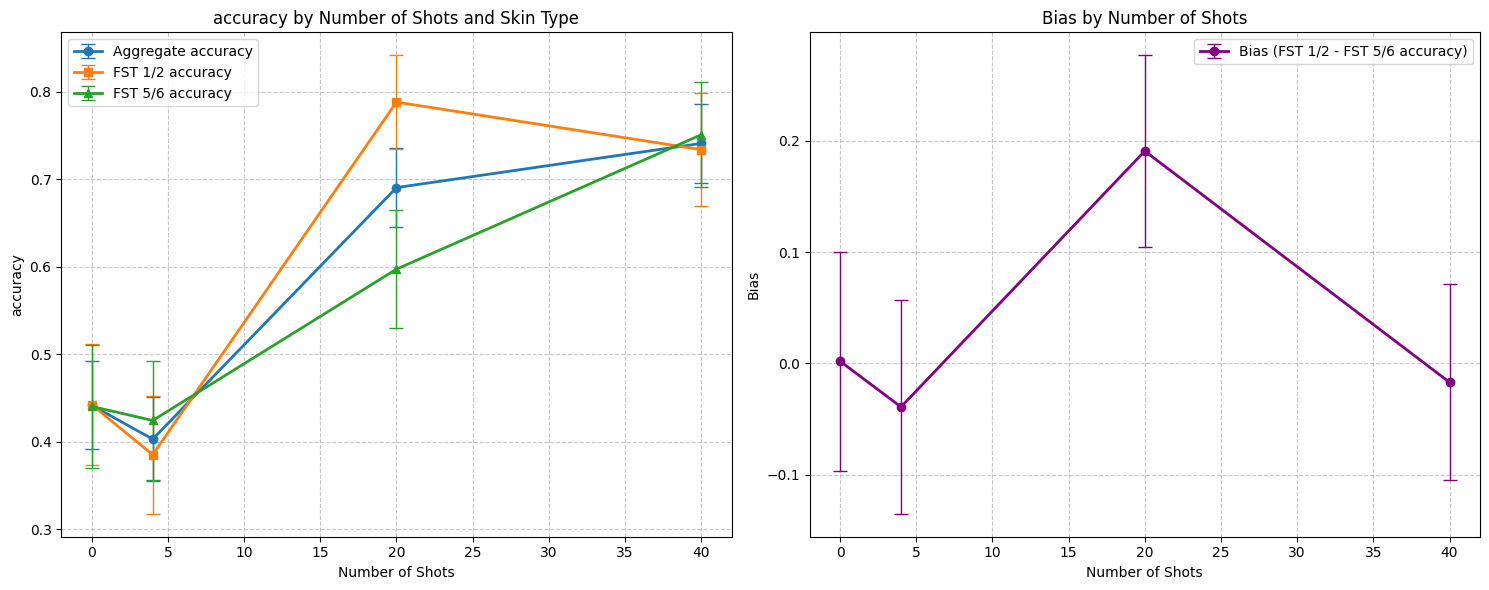

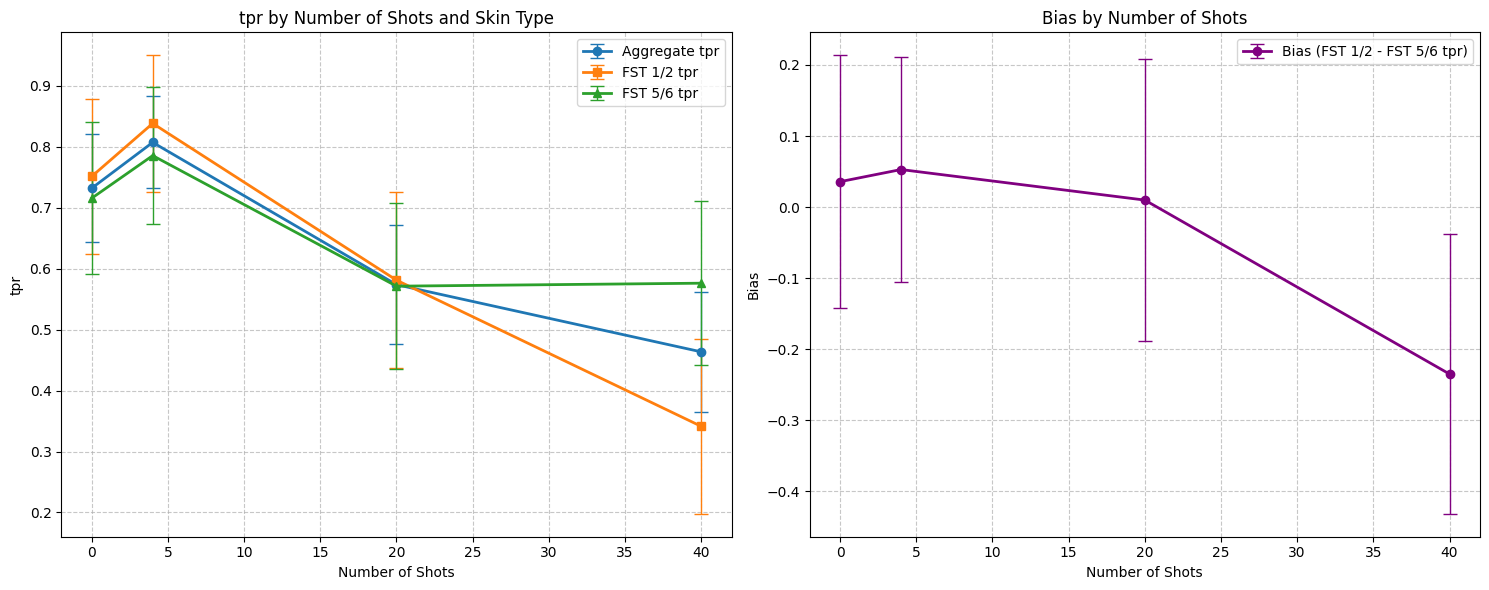

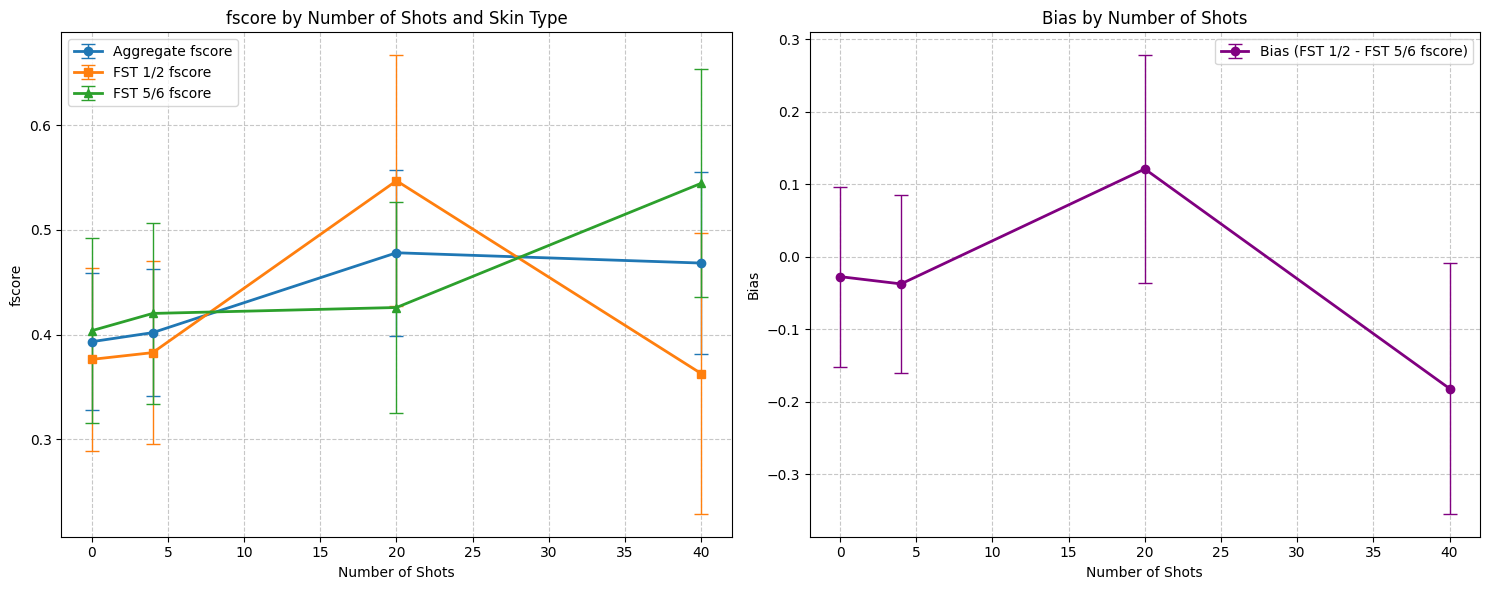

In [ ]:
# Plot with confidence intervals
shots = [0, 4, 20, 40]
plot_experiment_metrics_with_ci(bulk_metrics, fst12_metrics, fst56_metrics, "accuracy", shots, use_error_bars=True)
plot_experiment_metrics_with_ci(bulk_metrics, fst12_metrics, fst56_metrics, "tpr", shots, use_error_bars=True)
plot_experiment_metrics_with_ci(bulk_metrics, fst12_metrics, fst56_metrics, "fscore", shots, use_error_bars=True)

# add fst12

In [ ]:
exps = ["/home/joseph/Downloads/ddi_0_0_0_0_gpt-4o-2024-05-13_50.pkl",
        "/home/joseph/Downloads/ddi_3_1_0_0_gpt-4o-2024-05-13_50.pkl",
       "/home/joseph/Downloads/ddi_15_5_0_0_gpt-4o-2024-05-13_50.pkl",
       "/home/joseph/Downloads/ddi_30_10_0_0_gpt-4o-2024-05-13_50.pkl",
       ]

In [ ]:
bulk_metrics, fst12_metrics, fst56_metrics = calculate_bootstrap_metrics(exps)

In total 0 errors len = 104
In total 0 errors len = 104
In total 0 errors len = 104
In total 0 errors len = 104


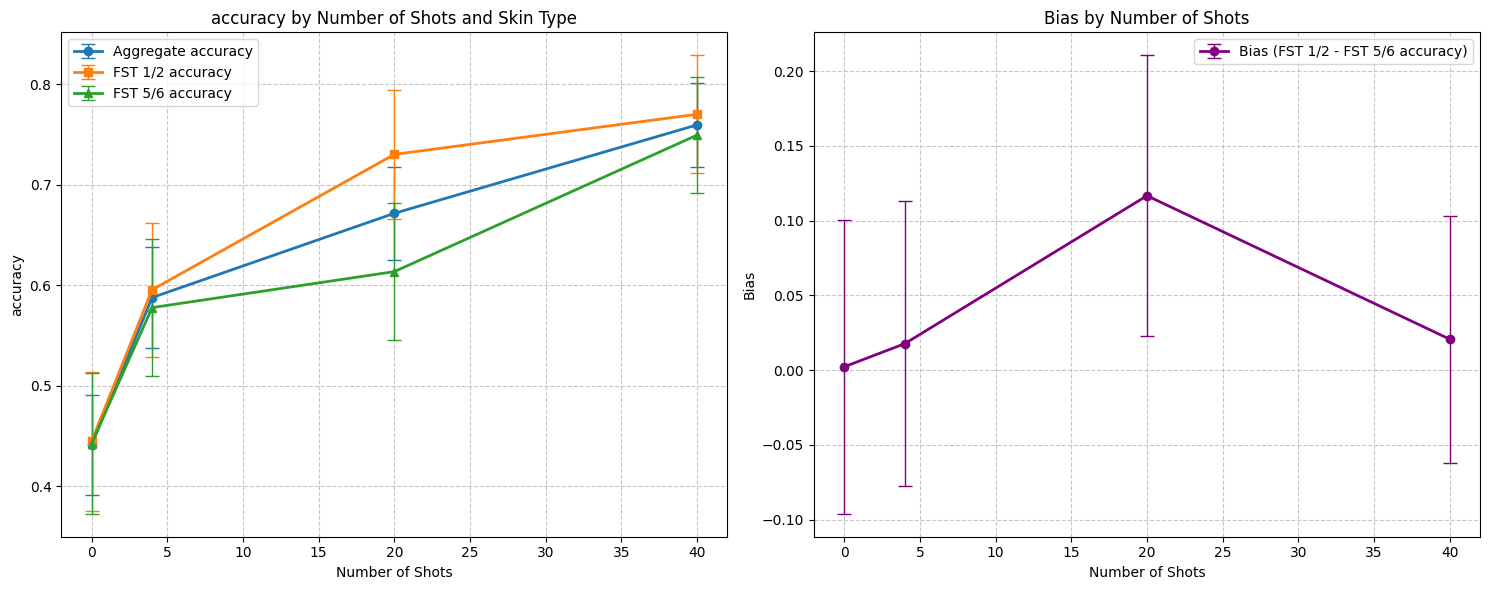

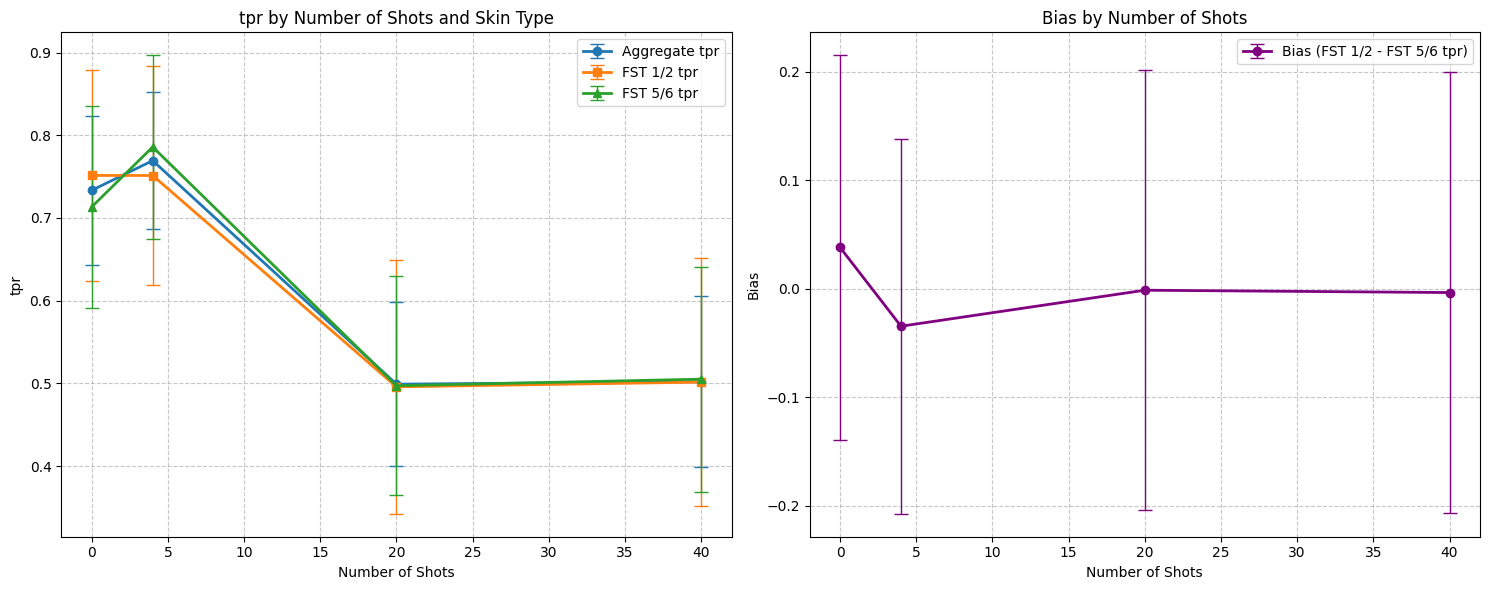

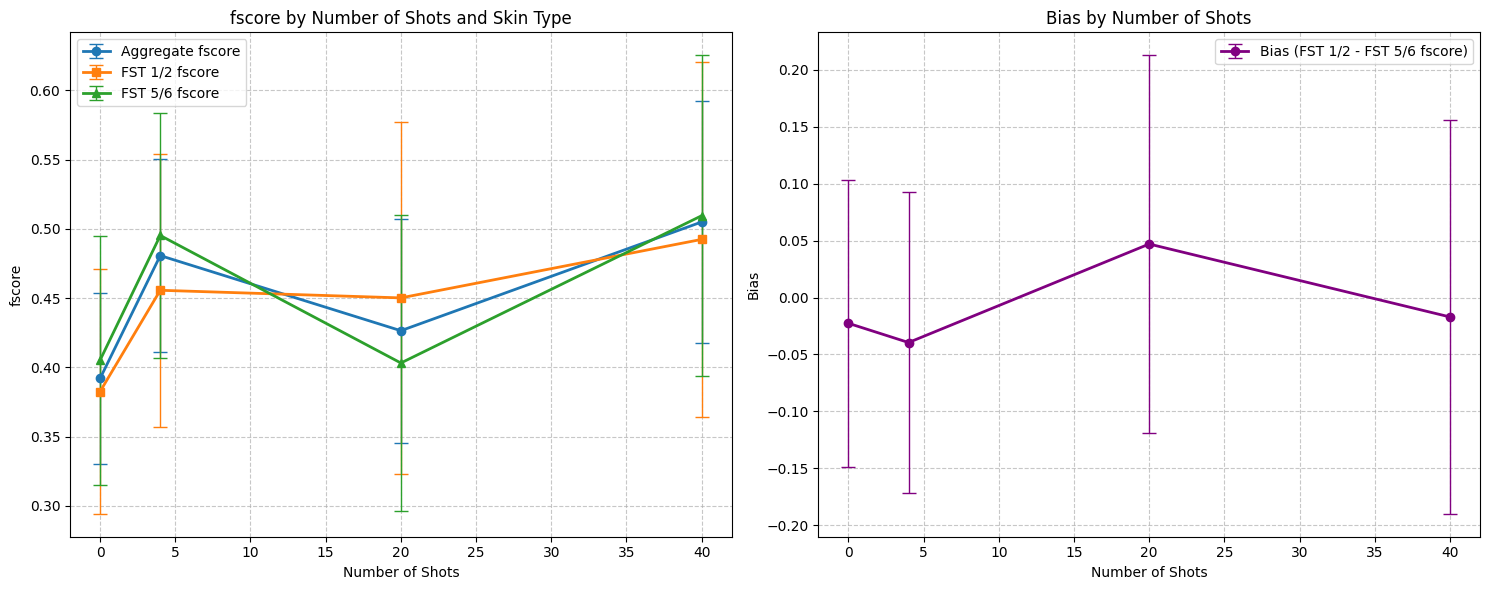

In [ ]:
# Plot with confidence intervals
shots = [0, 4, 20, 40]
plot_experiment_metrics_with_ci(bulk_metrics, fst12_metrics, fst56_metrics, "accuracy", shots, use_error_bars=True)
plot_experiment_metrics_with_ci(bulk_metrics, fst12_metrics, fst56_metrics, "tpr", shots, use_error_bars=True)
plot_experiment_metrics_with_ci(bulk_metrics, fst12_metrics, fst56_metrics, "fscore", shots, use_error_bars=True)

# add both

In [ ]:
exps = ["/home/joseph/Downloads/ddi_0_0_0_0_gpt-4o-2024-05-13_50.pkl",
        "/home/joseph/Downloads/ddi_3_1_3_1_gpt-4o-2024-05-13_50.pkl",
       "/home/joseph/Downloads/ddi_15_5_15_5_gpt-4o-2024-05-13_50.pkl",
       "/home/joseph/Downloads/ddi_30_10_30_10_gpt-4o-2024-05-13_50.pkl",
       ]

In [ ]:
bulk_metrics, fst12_metrics, fst56_metrics = calculate_bootstrap_metrics(exps)

In total 0 errors len = 104
In total 0 errors len = 104
In total 0 errors len = 104
In total 0 errors len = 104


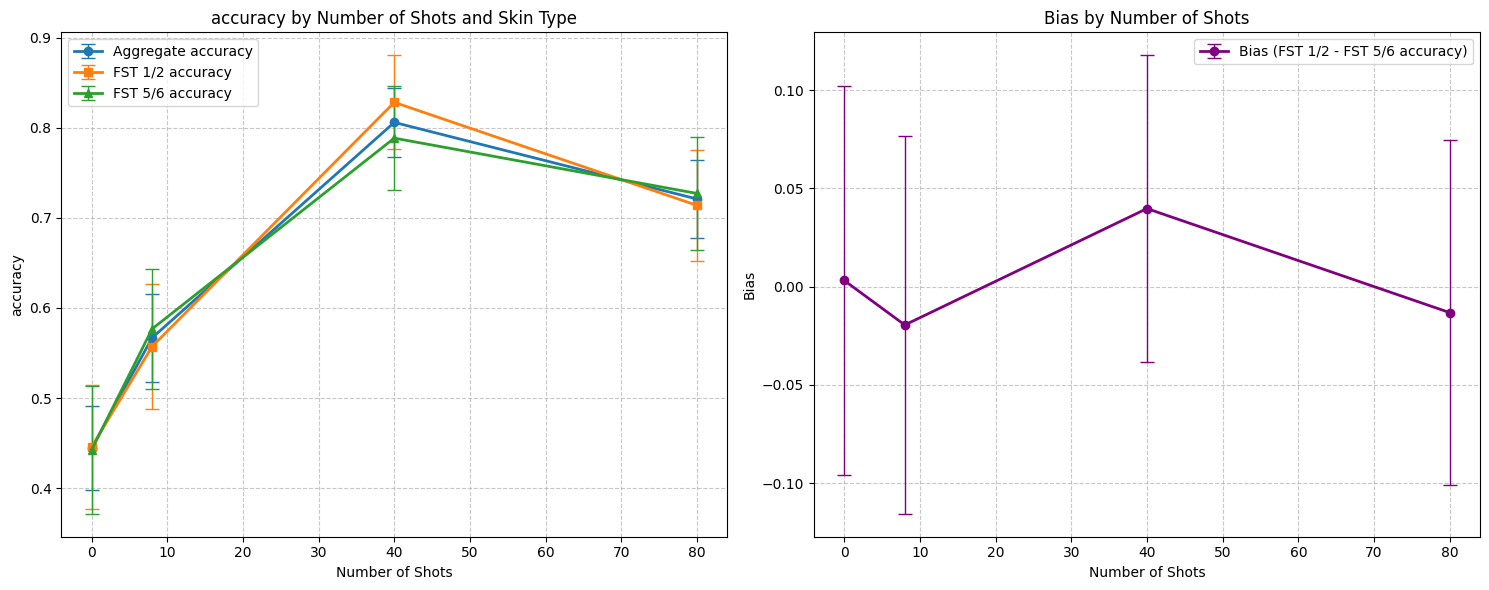

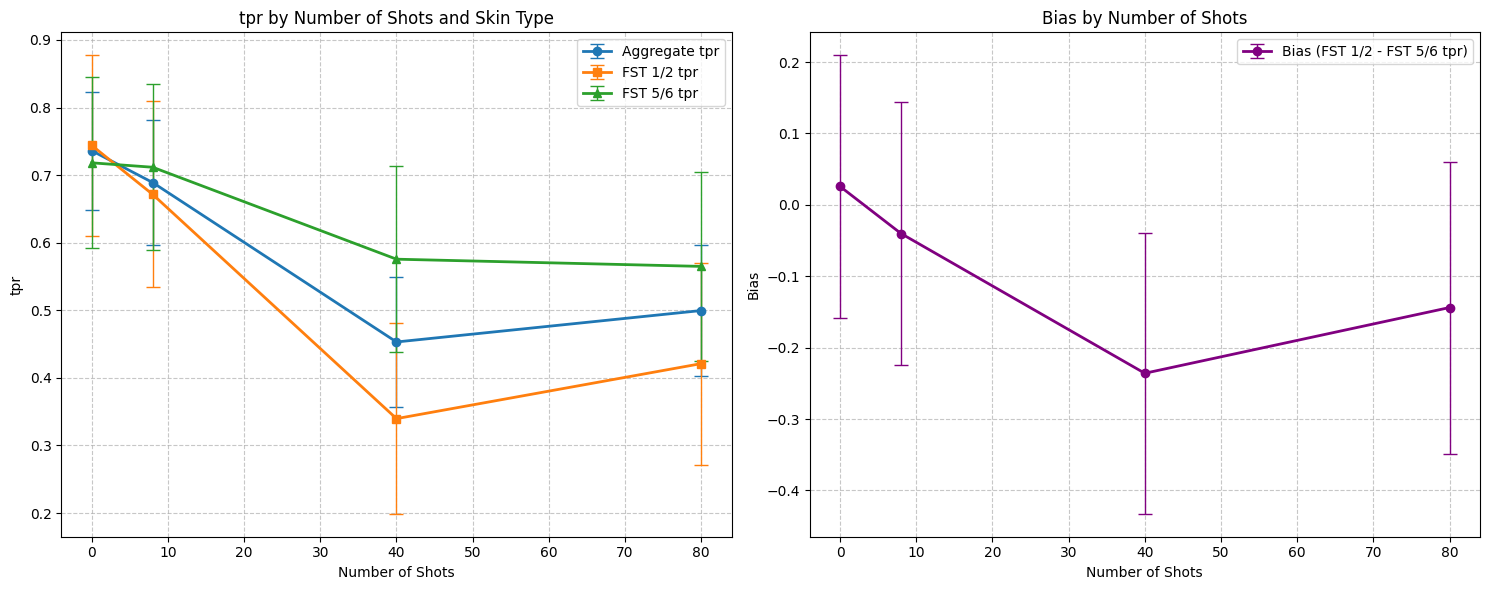

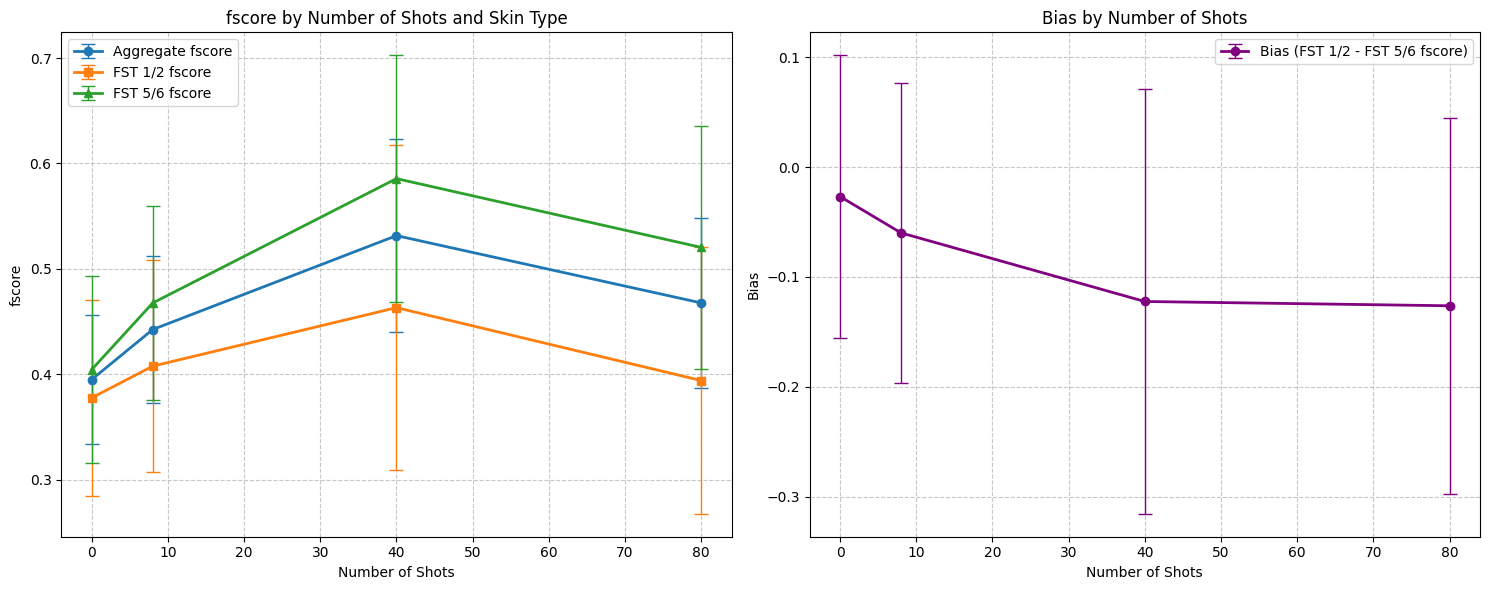

In [ ]:
# Plot with confidence intervals
shots = [0, 8, 40, 80]
plot_experiment_metrics_with_ci(bulk_metrics, fst12_metrics, fst56_metrics, "accuracy", shots, use_error_bars=True)
plot_experiment_metrics_with_ci(bulk_metrics, fst12_metrics, fst56_metrics, "tpr", shots, use_error_bars=True)
plot_experiment_metrics_with_ci(bulk_metrics, fst12_metrics, fst56_metrics, "fscore", shots, use_error_bars=True)